In [1]:
from topological_insulator import Problem

In [2]:
structure_path = "../../../../../topological_insulator/data/structures/"
structure_name = "kagome.json"

In [3]:
def _set_eigenvalues(problem:Problem, Delta_SOC, t, delta, U, occupations):
    sublattice_labels = ["A", "B", "C", "D", "E", "F"]
    cell = problem.cell_parser
    g = cell.geometry
    n_subs = len(g.delta_vectors.value)
    subs = sublattice_labels[:n_subs]
    for i, label_i in enumerate(subs):
        parser = getattr(problem.cell_parser.eigenvalues, label_i).value
        # Diagonal Values
        base = i * 8
        parser["chadi_soc"][label_i]["Delta_pp"] = Delta_SOC
        parser["interaction"][label_i]["U_p"] = U
        parser["interaction"][label_i]["n_px_up"] = occupations[2+base]
        parser["interaction"][label_i]["n_px_down"] = occupations[3+base]
        parser["interaction"][label_i]["n_py_up"] = occupations[4+base]
        parser["interaction"][label_i]["n_py_down"] = occupations[5+base]
        parser["interaction"][label_i]["n_pz_up"] = occupations[6+base]
        parser["interaction"][label_i]["n_pz_down"] = occupations[7+base]
        # Off-Diagonal Values
        for label_j in subs:
            # Hoppings
            try:
                parser["nn_hopping"][label_j]["t_pp_sigma"] = t - delta
                parser["nn_hopping"][label_j]["t_pp_pi"] = t + delta
            except:
                pass

In [4]:
location = "edge"
N_r = 10

In [5]:
Delta_SOC = -5
t = -1
delta = 0.832

# Spin-Liquid Occupations

x1 = [1.        , 1.        , 0.41481523, 0.41481523, 0.48031309,
       0.48031309, 0.62213433, 0.62213433, 1.        , 1.        ,
       0.41481523, 0.41481523, 0.48031309, 0.48031309, 0.62213433,
       0.62213433, 1.        , 1.        , 0.5117651 , 0.51176512,
       0.38189577, 0.38189579, 0.62120889, 0.62120888]

x3 = [1.        , 1.        , 0.41481523, 0.41481523, 0.48031309,
       0.48031309, 0.62213433, 0.62213433, 1.        , 1.        ,
       0.41481523, 0.41481523, 0.48031309, 0.48031309, 0.62213433,
       0.62213433, 1.        , 1.        , 0.5117651 , 0.51176512,
       0.38189577, 0.38189579, 0.62120889, 0.62120888]

cases = {
    0: {"U": 1, "x":x1},
    1: {"U": 3, "x":x3} 
}

In [6]:
results = {}
for n, U_dict in enumerate(cases.values()):
    U = U_dict["U"]
    x = U_dict["x"]
    print("")
    print(f"Running case for: delta/t_1 = {delta/t}, and U/t = {U/t}")
    problem = Problem(structure_path=structure_path, structure_name=structure_name)
    _set_eigenvalues(problem, Delta_SOC, t, delta, U, x)
    problem.setup(
        N_r = N_r,
        N_k = 200,
        location = location,
        BZ = "reduced",
        dangling_bonds=False
    )
    problem.run(
        H_type="reciprocal"
    )
    results[n] = problem


Running case for: delta/t_1 = -0.832, and U/t = -1.0
Building Geometry...
Geometry - Done.
Building 'Edge' Hamiltonian...
'Edge' Hamiltonian - Done.
Calculating 'Edge' eigenvalues...
'Edge' Eigenvalues - Done!

Running case for: delta/t_1 = -0.832, and U/t = -3.0
Building Geometry...
Geometry - Done.
Building 'Edge' Hamiltonian...
'Edge' Hamiltonian - Done.
Calculating 'Edge' eigenvalues...
'Edge' Eigenvalues - Done!


In [128]:
import numpy as np
edge_sites = [0, 1, 2, -3 -2, -1]
j_3_2 = [i for i in range (116, 231)] #[i for i in range (236, 471)]
threshold = 0.15
site_idx = 23

## Case 0

In [129]:
g = results[0].geometry
tb_edge = results[0].hamiltonian[location]["tight_binding"]
invariants = results[0].hamiltonian[location]["topological_invariants"]

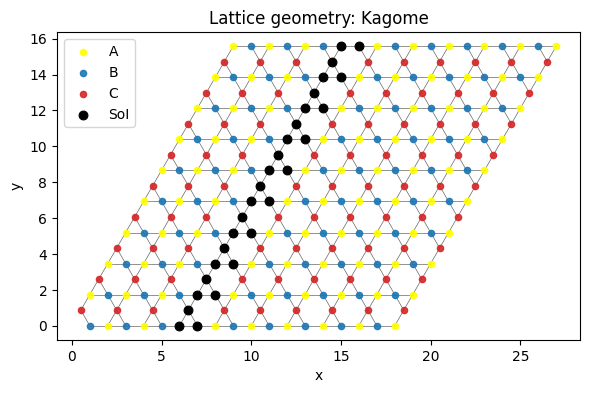

In [139]:
g.plot_lattice(
    sites_of_interest=tb_edge.sublattice_idxs
)

In [ ]:
LDOS_0, E_0 = invariants.get_local_density_of_states(
    site_idx = 0,
    E_max = 8.5, 
    E_min = 1.5,
    eta = 0.05
)

LDOS_23, E_23 = invariants.get_local_density_of_states(
    site_idx = 23,
    E_max = 7, 
    E_min = -2,
    eta = 0.05
)


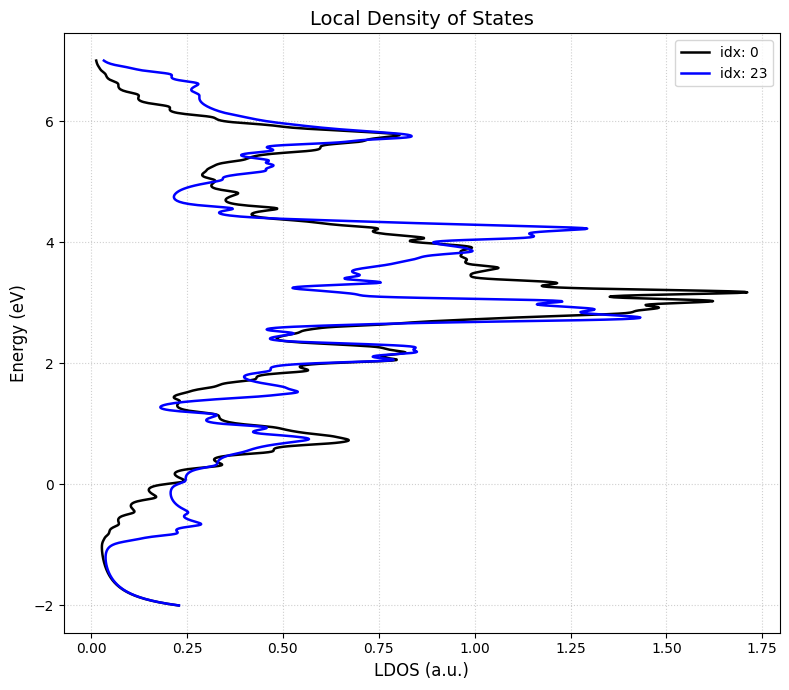

In [132]:
from matplotlib import pyplot as plt
xlabel:str = "LDOS"
figsize: tuple = (8, 7)
# idx_max = np.argmax(LDOS_0)
# E_peak = E[idx_max]
fig, ax = plt.subplots(figsize=figsize)
# ax.plot(E_vals, LDOS, color="k", lw=1.8)
ax.plot(E_0, LDOS_0, color="k", lw=1.8, label=f"idx: {0}")
ax.plot(E_23, LDOS_23, color="b", lw=1.8, label=f"idx: {23}")
# if True:
#     ax.axhline(
#         E_peak,
#         color="r",
#         linestyle='--',
#         linewidth=1.5,
#         label=f'Max {xlabel} at {E_peak:.2f} eV'
#     )
ax.set_ylabel("Energy (eV)", fontsize=12)
ax.set_xlabel(f"{xlabel} (a.u.)", fontsize=12)
if xlabel == "LDOS":
    ax.set_title("Local Density of States", fontsize=14)
else:
    ax.set_title("Total Density of States", fontsize=14)
ax.legend(frameon=True)
ax.grid(True, ls=':', alpha=0.6)

plt.tight_layout()
plt.show()

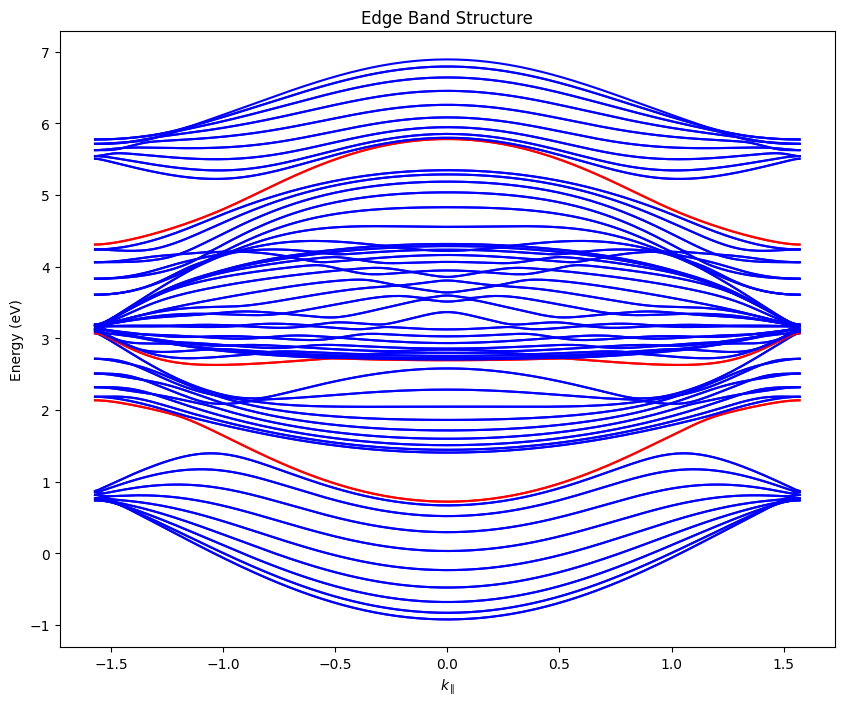

In [133]:
edge_bands_0 = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=-0.8, threshold=threshold)
edge_bands_1 = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=0.0, threshold=threshold)
edge_bands_2 = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=0.8, threshold=threshold)
edge_bands = np.unique(np.concatenate([edge_bands_0, edge_bands_1, edge_bands_2]))
tb_edge.plot_dispersion(g, j_3_2, edge_bands=edge_bands)

band idx: 134


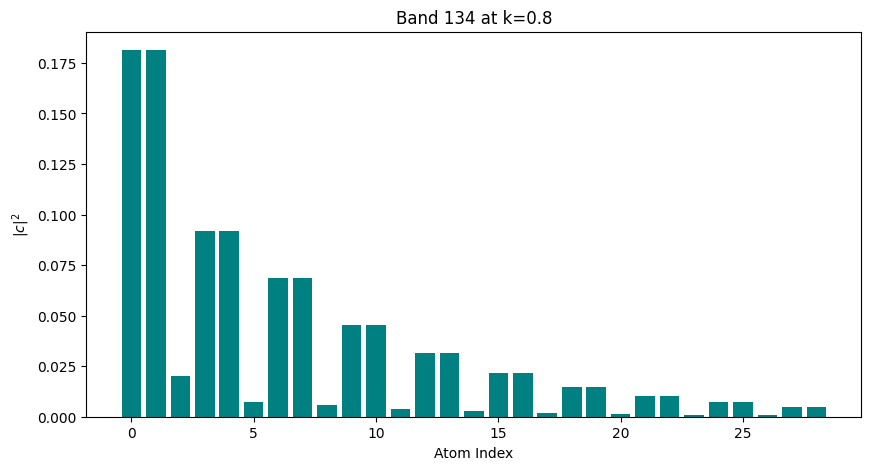

band idx: 135


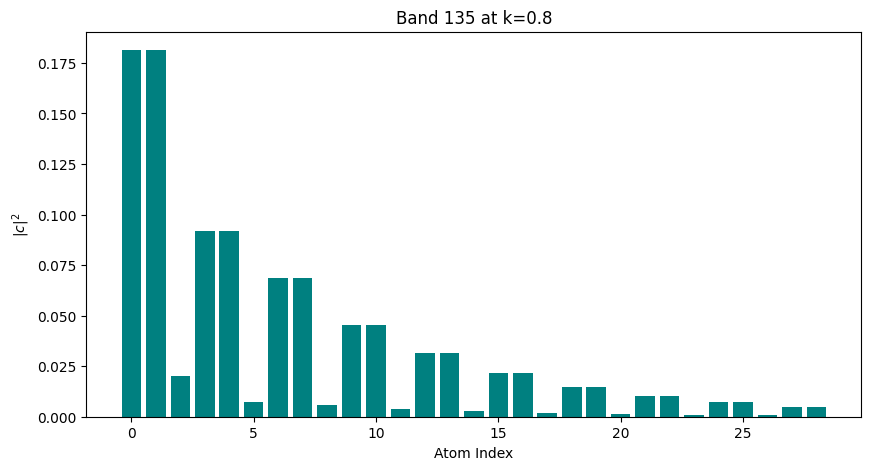

band idx: 154


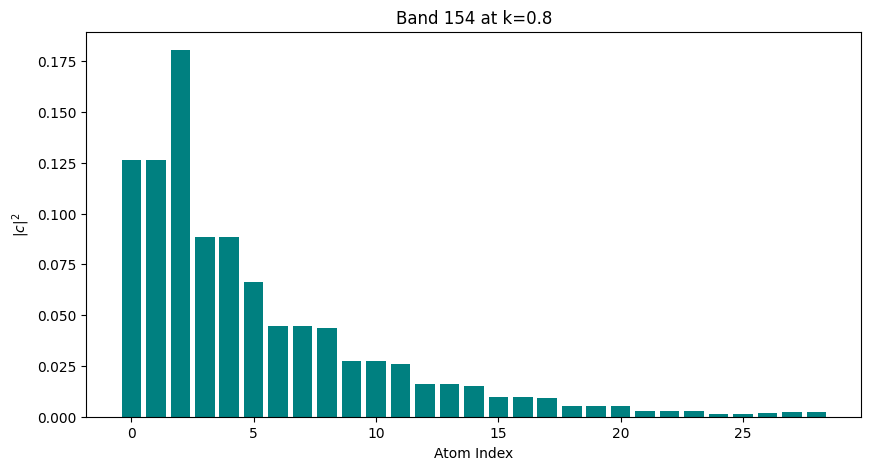

band idx: 155


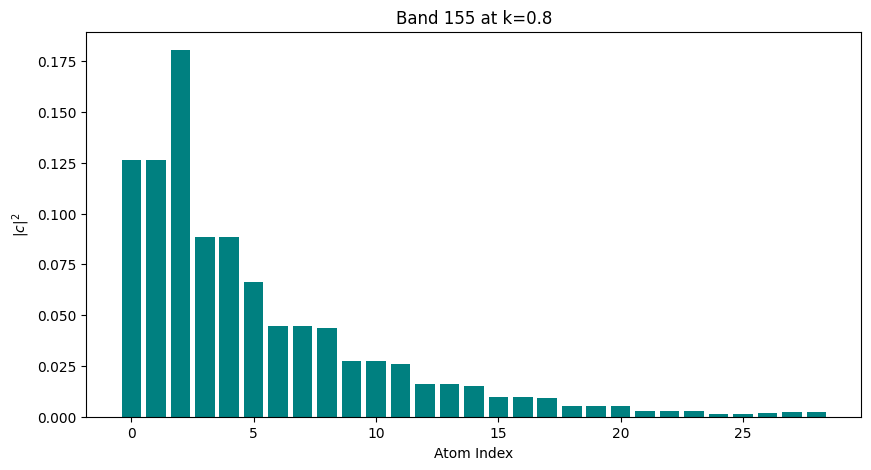

band idx: 212


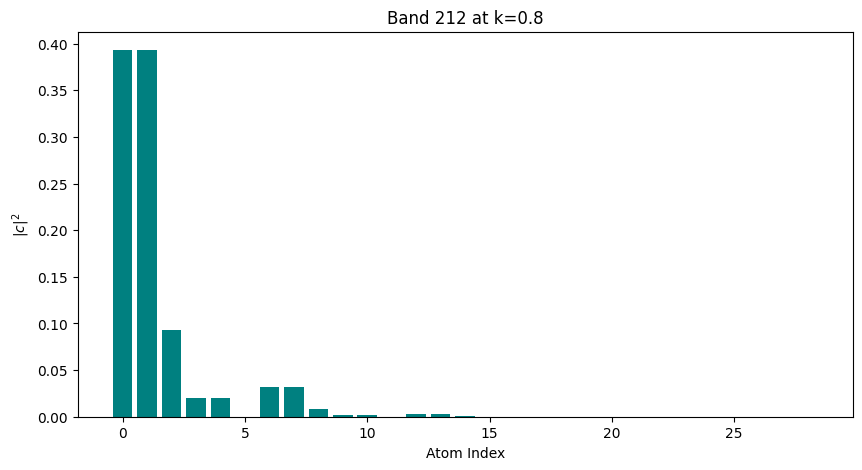

band idx: 213


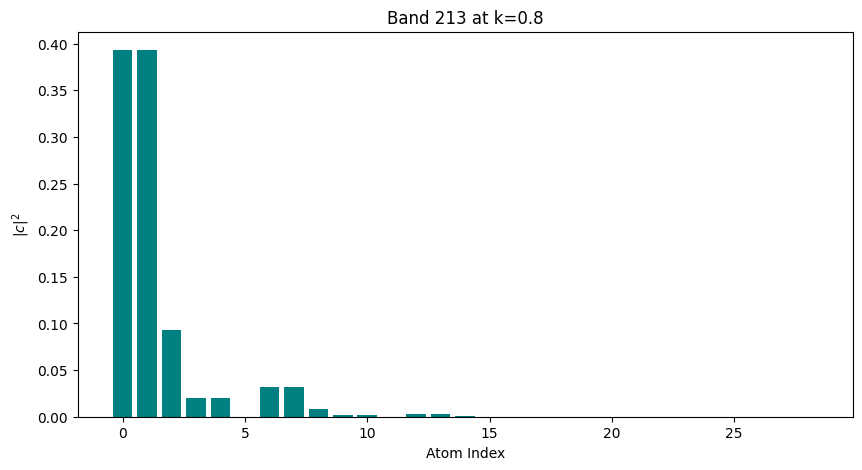

In [134]:
N_projections = len(tb_edge.coupled_states)
N_sites = len(tb_edge.sublattice_idxs)
N_bands = N_sites * N_projections

Psi_dict = tb_edge.band_structure_data["eigenvector_dict"]
for band in edge_bands:
    if band in edge_bands_0:
        k_target = -0.8
    elif band in edge_bands_1:
        k_target = 0.0
    else:
        k_target = 0.8
    if band < min(j_3_2):
        continue
    k_idx = np.argmin(np.abs(g.k_edge - k_target))
    Psi_k = Psi_dict[band][k_idx, :]
    total_norm = np.sum(np.abs(Psi_k)**2)
    print(f"band idx: {band}")
    n_atoms = len(tb_edge.sublattice_idxs)
    atomic_wavefunctions = {}
    atom_contributions = np.zeros(n_atoms)
    for i in range(n_atoms):
        start = i * N_projections
        end = start + N_projections
        orbital_block = Psi_k[start:end]  # Orbitals for atom i
        atom_contributions[i] = np.sum(np.abs(orbital_block)**2)
        atomic_wavefunctions[i] = Psi_k[start:end] 

    from matplotlib import pyplot as plt
    plt.figure(figsize=(10, 5))
    plt.bar(range(n_atoms), atom_contributions, color='teal')
    plt.xlabel("Atom Index")
    plt.ylabel(f"$|c|^2$")
    # plt.xlim(0, 10)
    plt.title(f"Band {band} at k={np.abs(g.k_edge[k_idx]):.1f}")
    plt.show()

## Case 1

In [135]:
g = results[1].geometry
tb_edge = results[1].hamiltonian[location]["tight_binding"]
invariants = results[1].hamiltonian[location]["topological_invariants"]

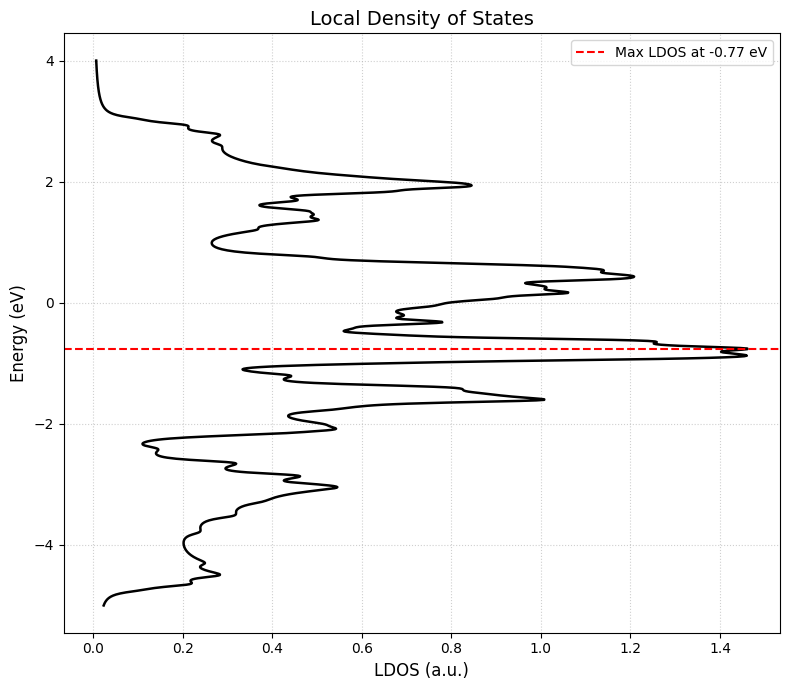

In [136]:
LDOS, E = invariants.get_local_density_of_states(
    site_idx = site_idx,
    E_max = 4, 
    E_min = -5,
    eta = 0.05
)
invariants.plot_density_of_states(LDOS, E)

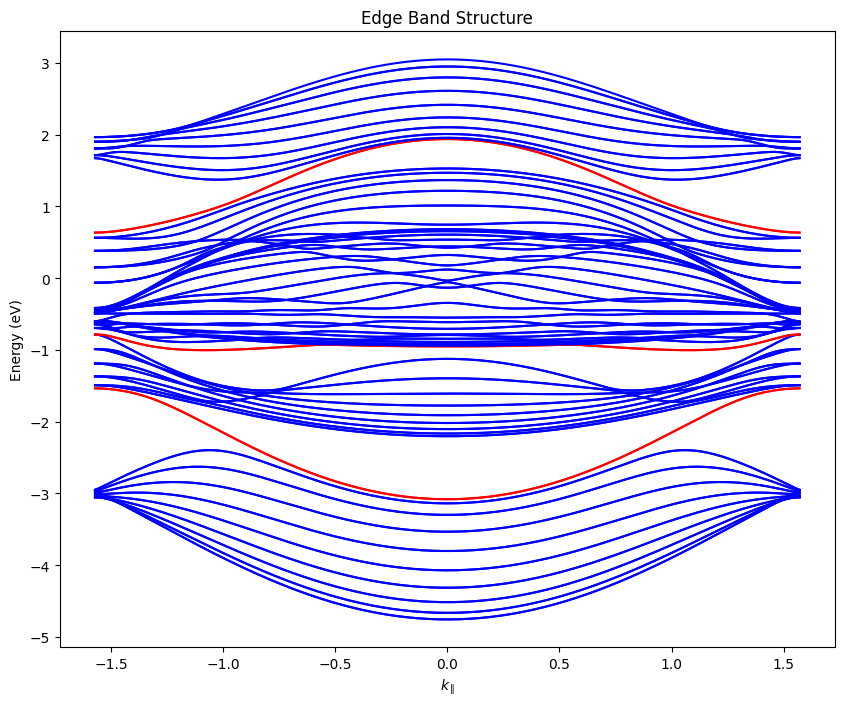

In [137]:
edge_bands_0 = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=-0.8, threshold=threshold)
edge_bands_1 = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=0.0, threshold=threshold)
edge_bands_2 = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=0.8, threshold=threshold)
edge_bands = np.unique(np.concatenate([edge_bands_0, edge_bands_1, edge_bands_2]))
tb_edge.plot_dispersion(g, j_3_2, edge_bands=edge_bands)

band idx: 134
{0: array([ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
        3.72428833e-02+0.00000000e+00j,  3.66262021e-11+4.33516259e-10j,
       -3.99520028e-10-4.91232089e-09j, -1.83609493e-01+1.00554417e-03j,
        1.03886927e-10+1.85622199e-09j,  3.52199605e-01+2.94092222e-02j])}
{0: array([ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
        3.72428833e-02+0.00000000e+00j,  3.66262021e-11+4.33516259e-10j,
       -3.99520028e-10-4.91232089e-09j, -1.83609493e-01+1.00554417e-03j,
        1.03886927e-10+1.85622199e-09j,  3.52199605e-01+2.94092222e-02j]), 1: array([-1.66533454e-16+1.04083409e-16j, -1.38777878e-17-2.68882139e-17j,
        3.70557308e-02+3.72896369e-03j,  5.10868015e-11+4.32050885e-10j,
       -5.94069849e-10-4.89260568e-09j, -1.82586140e-01-1.93844902e-02j,
        2.70604206e-10+1.83932762e-09j,  3.53374350e-01+6.00273931e-03j]), 2: array([-2.77555756e-17+1.11022302e-16j, -1.38777878e-16-2.21177243e-17j,
        2.4489315

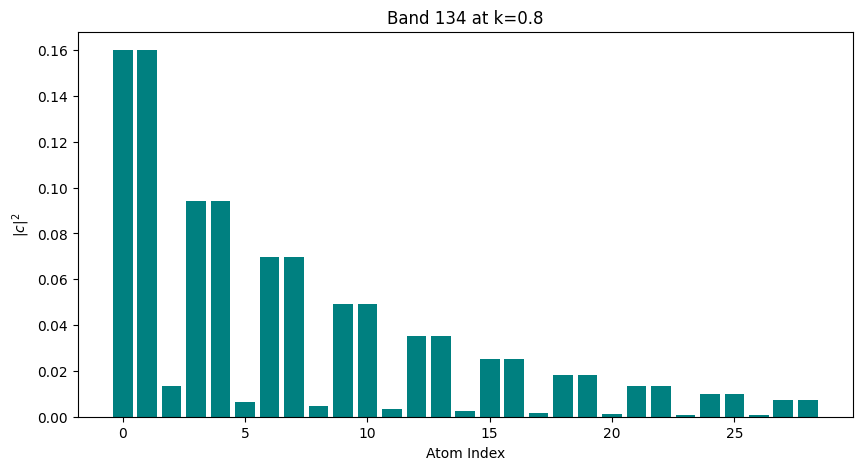

band idx: 135
{0: array([ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
        2.19372505e-09+0.00000000e+00j,  2.76435762e-02-2.49572644e-02j,
       -2.41712835e-01+2.57845631e-01j, -9.37058025e-09+2.65984827e-10j,
        1.36958210e-01-1.22294340e-01j,  2.48512659e-08-7.78984724e-11j])}
{0: array([ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
        2.19372505e-09+0.00000000e+00j,  2.76435762e-02-2.49572644e-02j,
       -2.41712835e-01+2.57845631e-01j, -9.37058025e-09+2.65984827e-10j,
        1.36958210e-01-1.22294340e-01j,  2.48512659e-08-7.78984724e-11j]), 1: array([-3.56167865e-16-1.24900090e-16j, -3.04833261e-18-6.93889390e-17j,
        2.19250094e-09+7.32781891e-11j,  2.50058026e-02-2.75996773e-02j,
       -2.58269983e-01+2.41259363e-01j, -9.35646610e-09-5.78846479e-10j,
        1.22534821e-01-1.36743097e-01j,  2.48347954e-08+9.07975889e-10j]), 2: array([-1.17348375e-17+1.61329283e-16j,  3.26935709e-17+2.84060969e-16j,
       -2.1207693

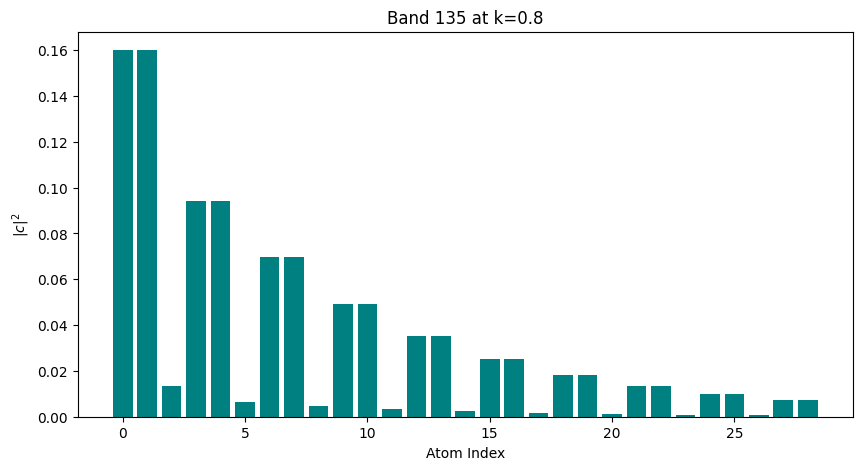

band idx: 154
{0: array([ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
       -1.74145564e-02+0.00000000e+00j, -5.63743496e-13-1.13419343e-12j,
       -3.40148743e-12-7.89481328e-14j,  2.05671159e-01+1.93866800e-01j,
       -6.61412591e-12-1.85104400e-11j,  2.30856930e-01+1.62754490e-01j])}
{0: array([ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
       -1.74145564e-02+0.00000000e+00j, -5.63743496e-13-1.13419343e-12j,
       -3.40148743e-12-7.89481328e-14j,  2.05671159e-01+1.93866800e-01j,
       -6.61412591e-12-1.85104400e-11j,  2.30856930e-01+1.62754490e-01j]), 1: array([-1.38777878e-17+0.00000000e+00j, -5.55111512e-17-2.94902991e-17j,
        1.47633559e-02-9.23634647e-03j,  6.88366031e-13-1.06310747e-12j,
        3.38826189e-12+3.06672391e-13j, -7.15364526e-02+2.73436460e-01j,
        8.66473560e-12-1.76434266e-11j, -1.09389302e-01+2.60418753e-01j]), 2: array([ 2.77555756e-17+2.77555756e-17j, -8.32667268e-17-2.28983499e-16j,
       -8.7686671

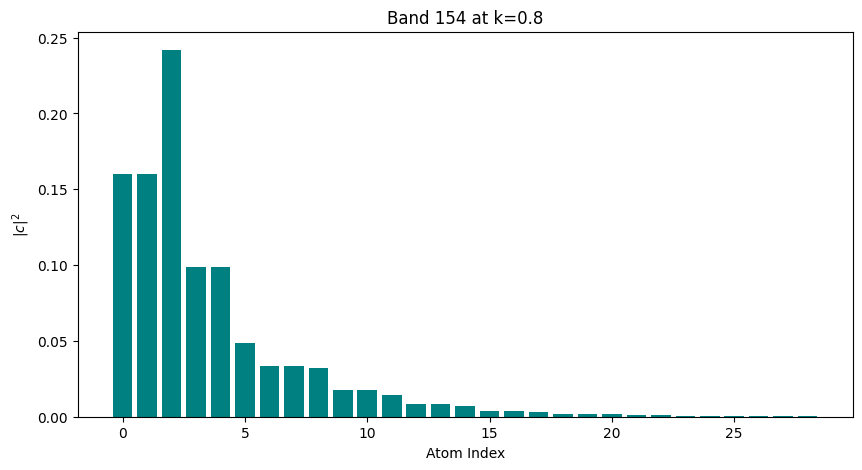

band idx: 155
{0: array([ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
       -1.41024320e-11+0.00000000e+00j,  1.15097903e-02+1.30687219e-02j,
        2.74718917e-01+6.56769550e-02j,  2.17340466e-10-2.57812117e-11j,
        2.81421086e-01+2.62133002e-02j,  1.76374280e-11+3.35242528e-11j])}
{0: array([ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
       -1.41024320e-11+0.00000000e+00j,  1.15097903e-02+1.30687219e-02j,
        2.74718917e-01+6.56769550e-02j,  2.17340466e-10-2.57812117e-11j,
        2.81421086e-01+2.62133002e-02j,  1.76374280e-11+3.35242528e-11j]), 1: array([ 1.86606068e-16-2.23779328e-16j, -1.94199192e-16+9.02056208e-17j,
       -7.19049770e-12+1.21318650e-11j, -2.82613454e-03-1.71837053e-02j,
        1.23132189e-01-2.54209382e-01j,  1.32993848e-10-1.73827071e-10j,
        1.57919365e-01-2.34406567e-01j, -1.98450492e-11-3.22681326e-11j]), 2: array([-7.68932673e-18+1.76941795e-16j,  1.35036183e-16+1.11022302e-16j,
        1.0088624

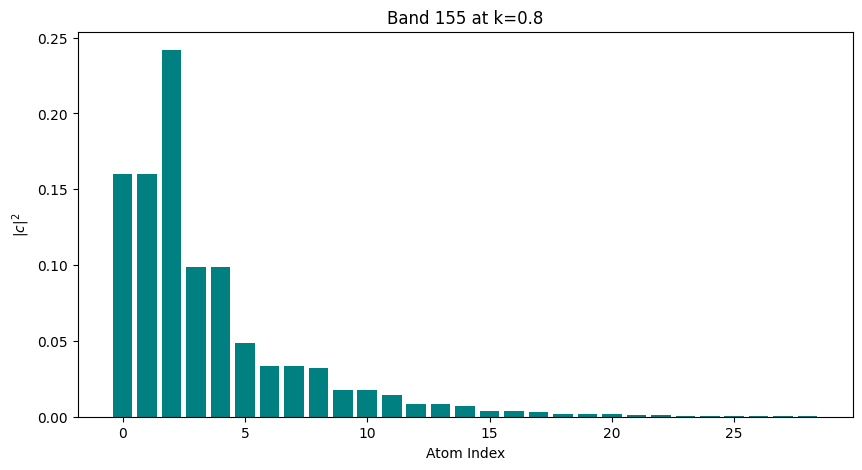

band idx: 212
{0: array([ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
        2.79508163e-02+0.00000000e+00j,  1.64146474e-13+4.46925483e-14j,
       -7.09432513e-14-7.87134247e-13j,  2.61327587e-01-1.39237427e-02j,
       -1.68666470e-12+4.76068696e-14j, -5.35362415e-01-2.76318904e-02j])}
{0: array([ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
        2.79508163e-02+0.00000000e+00j,  1.64146474e-13+4.46925483e-14j,
       -7.09432513e-14-7.87134247e-13j,  2.61327587e-01-1.39237427e-02j,
       -1.68666470e-12+4.76068696e-14j, -5.35362415e-01-2.76318904e-02j]), 1: array([-2.77555756e-17+2.77555756e-17j,  1.66533454e-16-9.10729825e-17j,
       -2.75449911e-02-4.74569259e-03j, -1.66922032e-13+3.25373618e-14j,
        1.29084243e-13-7.79191539e-13j, -2.55169229e-01-5.80916758e-02j,
        1.67843517e-12+1.72014163e-13j,  5.32280891e-01+6.36670231e-02j]), 2: array([-2.77555756e-17+9.71445147e-17j,  6.93889390e-18-4.16333634e-17j,
       -2.3511429

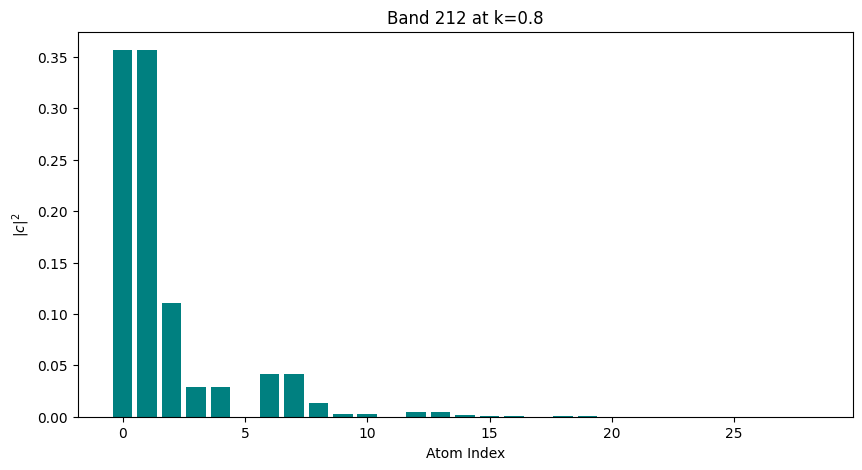

band idx: 213
{0: array([ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
       -9.59943175e-12+0.00000000e+00j,  1.86472353e-02-2.08213523e-02j,
        3.36580357e-01-4.17241052e-01j, -9.12012125e-11-2.76434038e-11j,
       -1.84715470e-01+1.85381148e-01j, -1.55751128e-11+4.17937293e-11j])}
{0: array([ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
       -9.59943175e-12+0.00000000e+00j,  1.86472353e-02-2.08213523e-02j,
        3.36580357e-01-4.17241052e-01j, -9.12012125e-11-2.76434038e-11j,
       -1.84715470e-01+1.85381148e-01j, -1.55751128e-11+4.17937293e-11j]), 1: array([-1.51286190e-16+9.02056208e-17j,  8.67764330e-17+0.00000000e+00j,
        8.61029258e-12+4.24386914e-12j, -1.48412907e-02+2.36851048e-02j,
       -3.07680945e-01+4.38986183e-01j,  9.40248776e-11+1.55228053e-11j,
        1.26960634e-01-2.28838311e-01j, -4.50903204e-12+4.43766413e-11j]), 2: array([-2.65828767e-16+5.03069808e-17j, -3.88273733e-16+6.31005664e-17j,
       -6.6934791

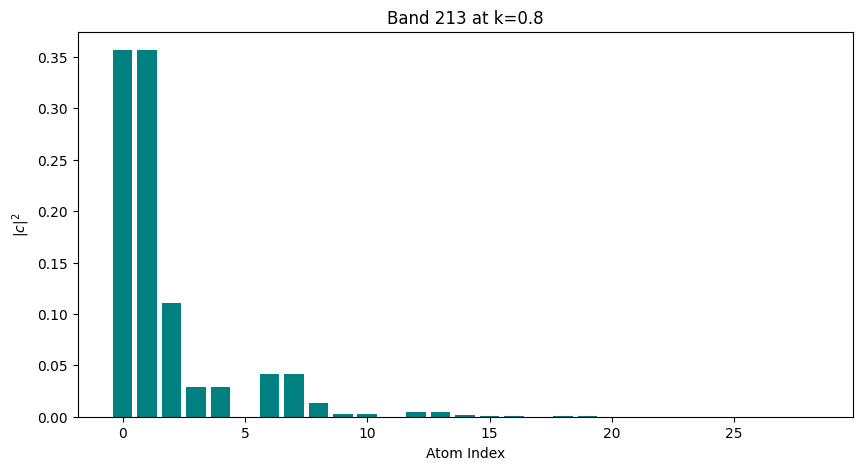

In [138]:
N_projections = len(tb_edge.coupled_states)
N_sites = len(tb_edge.sublattice_idxs)
N_bands = N_sites * N_projections

Psi_dict = tb_edge.band_structure_data["eigenvector_dict"]
for band in edge_bands:
    if band in edge_bands_0:
        k_target = -0.8
    elif band in edge_bands_1:
        k_target = 0.0
    else:
        k_target = 0.8
    if band < min(j_3_2):
        continue
    k_idx = np.argmin(np.abs(g.k_edge - k_target))
    Psi_k = Psi_dict[band][k_idx, :]
    total_norm = np.sum(np.abs(Psi_k)**2)
    print(f"band idx: {band}")
    n_atoms = len(tb_edge.sublattice_idxs)
    atomic_wavefunctions = {}
    atom_contributions = np.zeros(n_atoms)
    for i in range(n_atoms):
        start = i * N_projections
        end = start + N_projections
        orbital_block = Psi_k[start:end]  # Orbitals for atom i
        atom_contributions[i] = np.sum(np.abs(orbital_block)**2)
        atomic_wavefunctions[i] = Psi_k[start:end] 
        if i == 0 or i == 23:
            print(atomic_wavefunctions)

    from matplotlib import pyplot as plt
    plt.figure(figsize=(10, 5))
    plt.bar(range(n_atoms), atom_contributions, color='teal')
    plt.xlabel("Atom Index")
    plt.ylabel(f"$|c|^2$")
    # plt.xlim(0, 10)
    plt.title(f"Band {band} at k={np.abs(g.k_edge[k_idx]):.1f}")
    plt.show()